# Visión por Computadora I - Trabajo Práctico 3

Yoharlyn Alvarez

In [13]:
%matplotlib inline

import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from pathlib import Path

In [14]:
material_path = Path('../Material_TPs/TP3')
images_path = material_path / 'images'
template_path = material_path / 'template' / 'pattern.png'

image_paths = sorted(images_path.glob('*'))

## Exploración de las imágenes

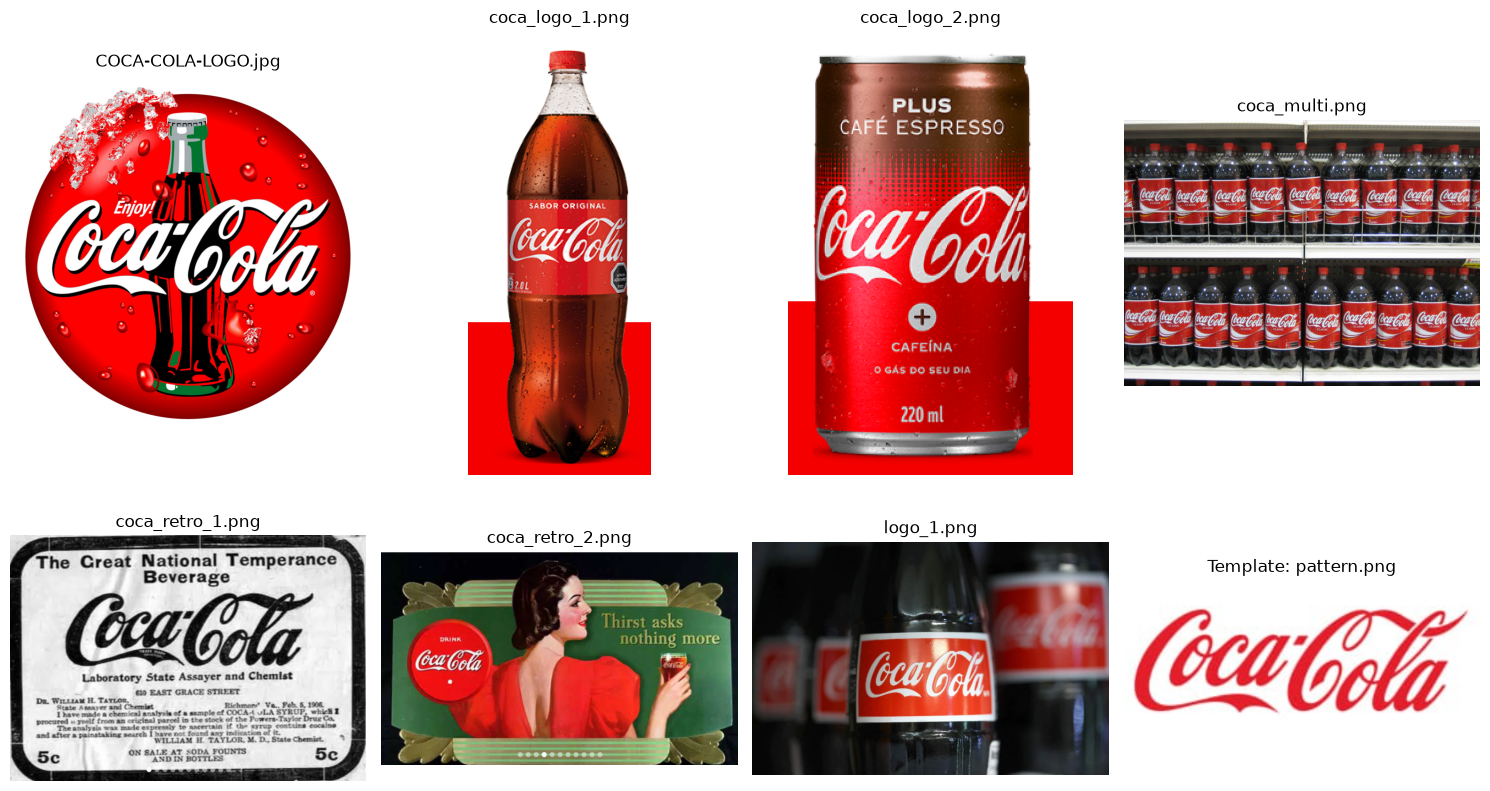

In [15]:
template_bgr = cv.imread(str(template_path))

if template_bgr is None:
    raise FileNotFoundError(f'No se pudo abrir el template: {template_path.resolve()}')

plt.figure(figsize=(15, 9))

for i, path in enumerate(image_paths):
    img_bgr = cv.imread(str(path))
    if img_bgr is None:
        raise FileNotFoundError(f'No se pudo abrir: {path.resolve()}')

    plt.subplot(2, 4, i + 1)
    plt.imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB))
    plt.title(path.name)
    plt.axis('off')

plt.subplot(2, 4, 8)
plt.imshow(cv.cvtColor(template_bgr, cv.COLOR_BGR2RGB))
plt.title('Template: pattern.png')
plt.axis('off')

plt.tight_layout()
plt.show()

Se observa que el logotipo cambia de tamaño. Además en la mayoría de las fotografías, las letras son claras sobre un fondo rojo. En el template ocurre lo contrario, las letras rojas están sobre fondo blanco.

## Preparación del template

El template tiene un margen blanco que no aporta información sobre la forma del logo. Se obtiene el rectángulo que contiene los píxeles que no son casi blancos y se recorta ese margen. Esto evita que el fondo domine la comparación.

Tamaño original: (400, 175)
Tamaño recortado: (378, 121)


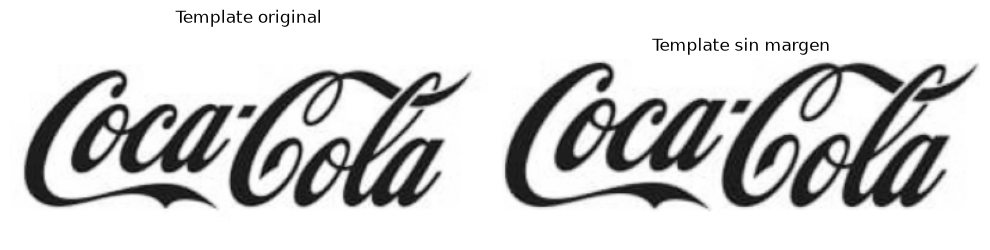

In [16]:
template_gray_completo = cv.cvtColor(template_bgr, cv.COLOR_BGR2GRAY)

y_logo, x_logo = np.where(template_gray_completo < 250)

x_min, x_max = x_logo.min(), x_logo.max() + 1
y_min, y_max = y_logo.min(), y_logo.max() + 1

template_gray = template_gray_completo[y_min:y_max, x_min:x_max]

print(f'Tamaño original: {template_gray_completo.shape[::-1]}')
print(f'Tamaño recortado: {template_gray.shape[::-1]}')

plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.imshow(template_gray_completo, cmap='gray')
plt.title('Template original')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(template_gray, cmap='gray')
plt.title('Template sin margen')
plt.axis('off')

plt.tight_layout()
plt.show()

## 1. Detección en cada imagen

`TM_CCOEFF_NORMED` entrega valores entre -1 y 1. Una correlación cercana a 1 indica igual contraste. Una correlación cercana a -1 también puede indicar el mismo patrón, pero con el contraste invertido.

Por eso se usa:

- `polaridad = 1` cuando el logo es oscuro sobre fondo claro (contraste similar al template).
- `polaridad = -1` cuando el logo es claro sobre fondo rojo (contraste invertido).

Como los logos tienen tamaños diferentes, se probaron varias escalas del template. En `coca_logo_2.png` también fue necesario modificar un poco el alto, ya que el logo de la lata se ve más estirado que el original.

Finalmente, para elegir la mejor detección se tuvo en cuenta la confianza y la escala. Esto ayuda a evitar que un detalle pequeño de la imagen sea seleccionado por error como la mejor coincidencia.

In [17]:
def mejor_deteccion(imagen_bgr, template, escalas, polaridad=-1, factores_alto=(1.0,)):
    imagen_gray = cv.cvtColor(imagen_bgr, cv.COLOR_BGR2GRAY)
    mejor = None

    for escala in escalas:
        for factor_alto in factores_alto:
            ancho = int(template.shape[1] * escala)
            alto = int(template.shape[0] * escala * factor_alto)

            if ancho > imagen_gray.shape[1] or alto > imagen_gray.shape[0]:
                continue

            interpolacion = cv.INTER_AREA if escala < 1 else cv.INTER_CUBIC
            template_escalado = cv.resize(template, (ancho, alto), interpolation=interpolacion)
            
            resultado = cv.matchTemplate(imagen_gray, template_escalado, cv.TM_CCOEFF_NORMED)

            mapa_confianza = polaridad * resultado
            _, confianza, _, posicion = cv.minMaxLoc(mapa_confianza)

            # Penalización para coincidencias demasiado pequeñas
            puntaje_ajustado = confianza * np.sqrt(escala * factor_alto)

            if mejor is None or puntaje_ajustado > mejor['puntaje_ajustado']:
                x, y = posicion
                mejor = {
                    'x1': x,
                    'y1': y,
                    'x2': x + ancho,
                    'y2': y + alto,
                    'confianza': float(confianza),
                    'escala': float(escala),
                    'factor_alto': float(factor_alto),
                    'puntaje_ajustado': float(puntaje_ajustado)
                }

    return mejor


def dibujar_detecciones(imagen_bgr, detecciones):
    salida = imagen_bgr.copy()

    for deteccion in detecciones:
        x1, y1 = deteccion['x1'], deteccion['y1']
        x2, y2 = deteccion['x2'], deteccion['y2']
        confianza = deteccion['confianza']

        cv.rectangle(salida, (x1, y1), (x2, y2), (0, 255, 0), 3)
        cv.putText(salida, f'{confianza:.2f}', (x1, max(20, y1 - 8)), cv.FONT_HERSHEY_SIMPLEX, 0.65, (0, 255, 0), 2)

    return salida

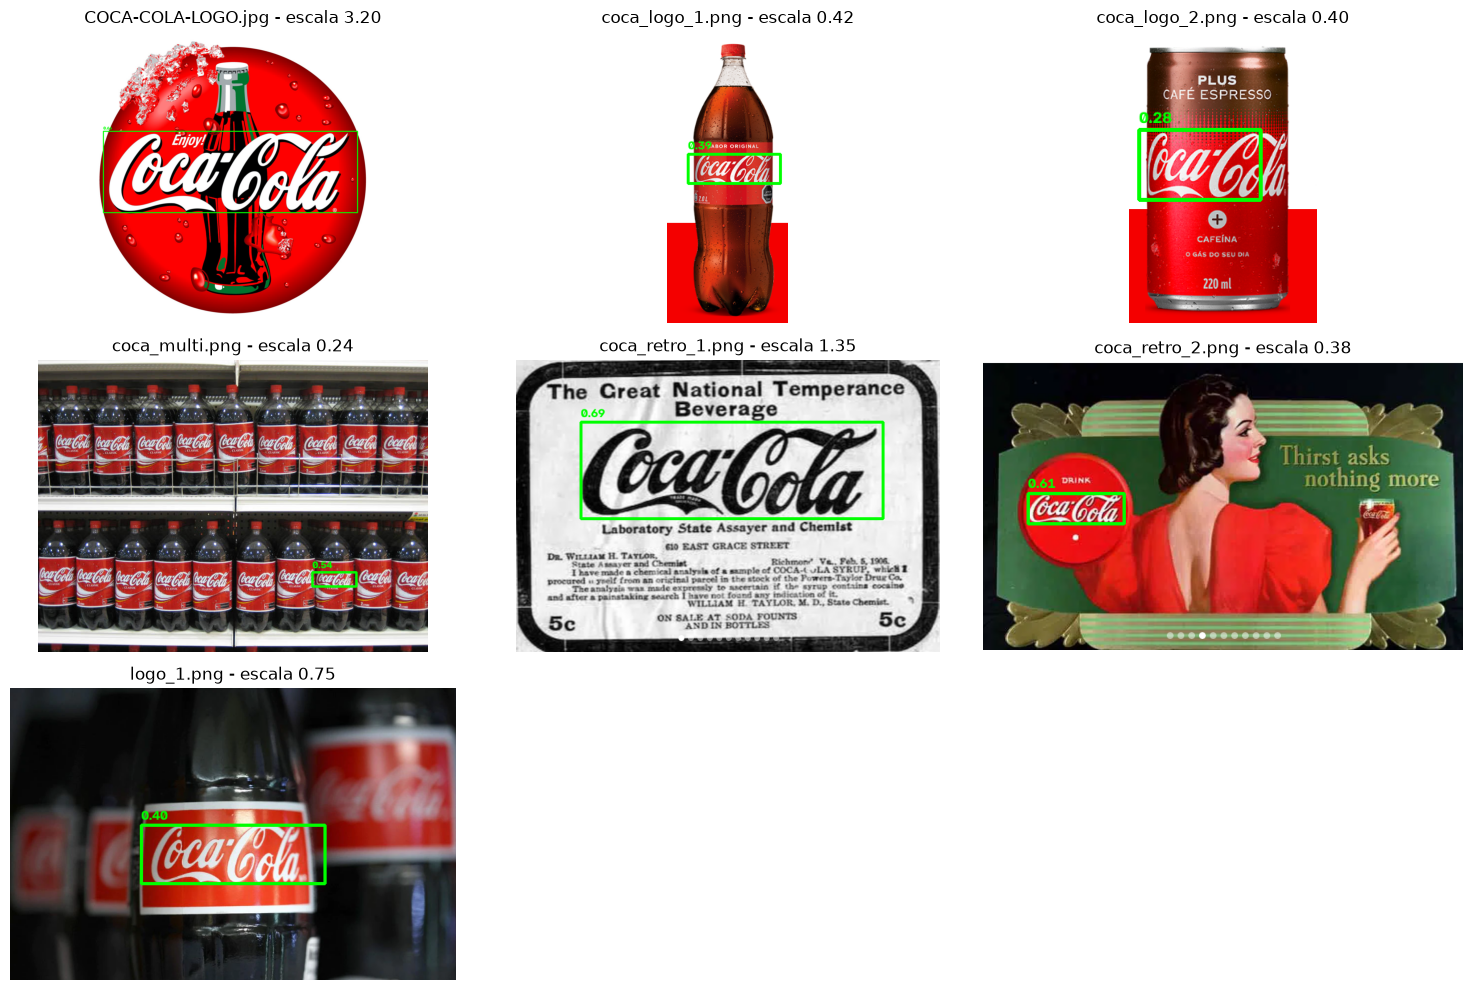

In [18]:
# Como matchTemplate no es invariante a escala, estimamos la escala
# comparando el ancho aproximado del logo con el ancho del template:
# escala_aproximada = ancho_logo / ancho_template
#
# Luego buscamos en un intervalo alrededor de esa estimación.
config_item_1 = {
    'COCA-COLA-LOGO.jpg': (np.arange(2.8, 3.41, 0.1), -1, (1.0,)),
    'coca_logo_1.png':    (np.arange(0.30, 0.51, 0.02), -1, (1.0,)),
    'coca_logo_2.png':    (np.arange(0.38, 0.51, 0.02), -1, np.arange(1.4, 1.81, 0.1)),
    'coca_multi.png':     (np.arange(0.18, 0.25, 0.01), -1, (1.0,)),
    'coca_retro_1.png':   (np.arange(1.10, 1.51, 0.05),  1, (1.0,)),
    'coca_retro_2.png':   (np.arange(0.30, 0.51, 0.02), -1, (1.0,)),
    'logo_1.png':         (np.arange(0.60, 0.91, 0.05), -1, (1.0,))
}

plt.figure(figsize=(15, 10))

for i, path in enumerate(image_paths):
    img_bgr = cv.imread(str(path))
    escalas, polaridad, factores_alto = config_item_1[path.name]

    deteccion = mejor_deteccion(img_bgr, template_gray, escalas, polaridad, factores_alto)
    resultado = dibujar_detecciones(img_bgr, [deteccion])

    plt.subplot(3, 3, i + 1)
    plt.imshow(cv.cvtColor(resultado, cv.COLOR_BGR2RGB))
    plt.title(f"{path.name} - escala {deteccion['escala']:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()

En este primer punto se conserva solamente la coincidencia de mayor puntaje en cada imagen. De esta manera se obtiene una detección por imagen y se evitan falsos positivos.

## 2. Múltiples detecciones

Al buscar varios logos, muchos píxeles cercanos pueden superar el umbral de confianza. Si se dibujara una caja en cada uno de esos puntos, aparecerían varias cajas sobre un mismo logo. Para evitarlo se aplicaron tres pasos:

1. Se conservaron solamente los puntos con mayor confianza dentro de cada zona.
2. Se descartaron las regiones que no contenían suficiente color rojo.
3. Se compararon las cajas superpuestas y se dejó solamente la de mayor confianza.

Para identificar el color rojo se utilizó el espacio HSV. En OpenCV, el rojo aparece en los dos extremos del canal H, por lo que fue necesario considerar ambos intervalos.

In [19]:
def proporcion_rojo(imagen_hsv, x1, y1, x2, y2):
    roi = imagen_hsv[y1:y2, x1:x2]

    tono = roi[:, :, 0]
    saturacion = roi[:, :, 1]
    valor = roi[:, :, 2]

    mascara_roja = (((tono < 12) | (tono > 170)) & (saturacion > 80) & (valor > 50))

    return np.mean(mascara_roja)


def buscar_candidatos(imagen_bgr, template, escalas, umbral, polaridad=-1, minimo_rojo=0, factores_alto=(1.0,)):
    imagen_gray = cv.cvtColor(imagen_bgr, cv.COLOR_BGR2GRAY)
    imagen_hsv = cv.cvtColor(imagen_bgr, cv.COLOR_BGR2HSV)
    candidatos = []

    for escala in escalas:
        for factor_alto in factores_alto:
            ancho = int(template.shape[1] * escala)
            alto = int(template.shape[0] * escala * factor_alto)

            if ancho > imagen_gray.shape[1] or alto > imagen_gray.shape[0]:
                continue

            interpolacion = cv.INTER_AREA if escala < 1 else cv.INTER_CUBIC
            template_escalado = cv.resize(template, (ancho, alto), interpolation=interpolacion)

            resultado = cv.matchTemplate(imagen_gray, template_escalado, cv.TM_CCOEFF_NORMED)
            mapa_confianza = polaridad * resultado

            maximos_locales = cv.dilate(mapa_confianza, np.ones((11, 11), dtype='uint8'))
            mascara = ((mapa_confianza >= umbral) & (mapa_confianza == maximos_locales))

            coordenadas_y, coordenadas_x = np.where(mascara)

            for x, y in zip(coordenadas_x, coordenadas_y):
                x2, y2 = x + ancho, y + alto
                rojo = proporcion_rojo(imagen_hsv, x, y, x2, y2)

                if rojo >= minimo_rojo:
                    candidatos.append({
                        'x1': int(x),
                        'y1': int(y),
                        'x2': int(x2),
                        'y2': int(y2),
                        'confianza': float(mapa_confianza[y, x]),
                        'escala': float(escala),
                        'factor_alto': float(factor_alto),
                        'puntaje_ajustado': float(mapa_confianza[y, x] * np.sqrt(escala * factor_alto))
                    })

    return candidatos

In [20]:
def calcular_iou(caja_a, caja_b):
    x1 = max(caja_a['x1'], caja_b['x1'])
    y1 = max(caja_a['y1'], caja_b['y1'])
    x2 = min(caja_a['x2'], caja_b['x2'])
    y2 = min(caja_a['y2'], caja_b['y2'])

    interseccion = max(0, x2 - x1) * max(0, y2 - y1)

    area_a = ((caja_a['x2'] - caja_a['x1']) * (caja_a['y2'] - caja_a['y1']))
    area_b = ((caja_b['x2'] - caja_b['x1']) * (caja_b['y2'] - caja_b['y1']))

    union = area_a + area_b - interseccion
    return interseccion / union if union > 0 else 0


def suprimir_repetidos(candidatos, umbral_iou=0.25):
    # Primero se procesan las cajas con mayor confianza
    ordenados = sorted(candidatos, key=lambda d: d['confianza'], reverse=True)
    seleccionados = []

    for candidato in ordenados:
        existe_superposicion = False

        for elegido in seleccionados:
            if calcular_iou(candidato, elegido) > umbral_iou:
                existe_superposicion = True
                break

        if not existe_superposicion:
            seleccionados.append(candidato)

    return seleccionados

Candidatos antes de la supresión: 84
Logos detectados: 18


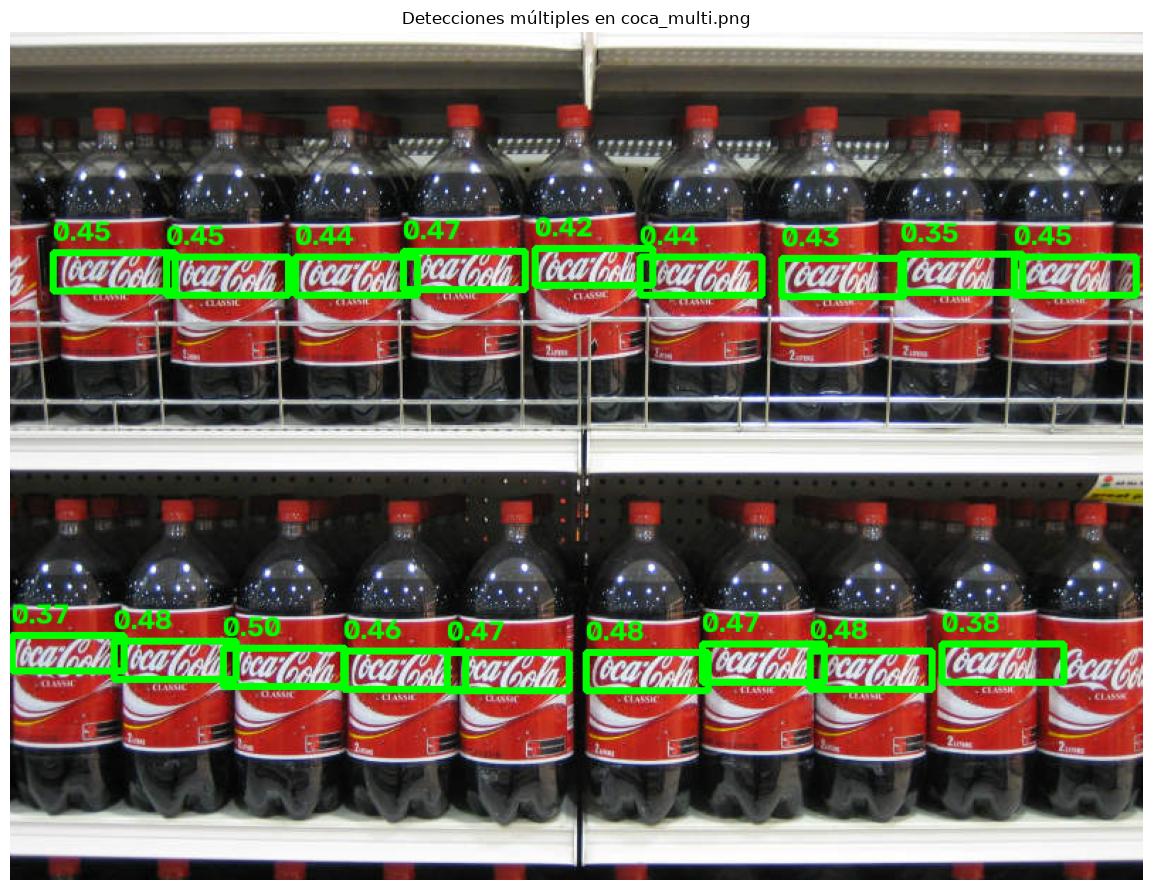

In [21]:
multi_path = images_path / 'coca_multi.png'
img_multi = cv.imread(str(multi_path))

escalas_multi = np.arange(0.14, 0.24, 0.01)

candidatos_multi = buscar_candidatos(img_multi, template_gray, escalas=escalas_multi, umbral=0.31, polaridad=-1, minimo_rojo=0.30)
detecciones_multi = suprimir_repetidos(candidatos_multi, umbral_iou=0.25)

print(f'Candidatos antes de la supresión: {len(candidatos_multi)}')
print(f'Logos detectados: {len(detecciones_multi)}')

resultado_multi = dibujar_detecciones(img_multi, detecciones_multi)

plt.figure(figsize=(14, 9))
plt.imshow(cv.cvtColor(resultado_multi, cv.COLOR_BGR2RGB))
plt.title('Detecciones múltiples en coca_multi.png')
plt.axis('off')
plt.tight_layout()
plt.show()

Se detectan los 18 logos completos de la imagen. Los logos cortados por los bordes no superan el umbral porque el template no puede compararse completo con ellos.

## 3. Generalización para todas las imágenes

Se encapsuló el procedimiento anterior en una única función para poder aplicarlo a todas las imágenes. El algoritmo mantiene los mismos pasos, pero utiliza distintos intervalos de escala y umbrales según el tamaño observado del logo. Como `coca_multi.png` contiene múltiples logos, en esa imagen se conservan todas las detecciones válidas. En las demás imágenes se conserva solamente la detección con mayor puntaje.

In [22]:
def detectar_logos(imagen_bgr, template, escalas, umbral, polaridad=-1, minimo_rojo=0, max_detecciones=None, factores_alto=(1.0,)):
    candidatos = buscar_candidatos(imagen_bgr, template, escalas, umbral, polaridad, minimo_rojo, factores_alto)
    detecciones = suprimir_repetidos(candidatos, umbral_iou=0.25)

    if max_detecciones is not None:
        detecciones = sorted(detecciones, key=lambda d: d['puntaje_ajustado'], reverse=True)[:max_detecciones]

    return detecciones

In [23]:
config_general = {
    'COCA-COLA-LOGO.jpg': {
        'escalas': np.arange(2.8, 3.41, 0.1),
        'umbral': 0.45, 'polaridad': -1, 'max_detecciones': 1
    },
    'coca_logo_1.png': {
        'escalas': np.arange(0.30, 0.51, 0.02),
        'umbral': 0.20, 'polaridad': -1, 'max_detecciones': 1
    },
    'coca_logo_2.png': {
        'escalas': np.arange(0.38, 0.51, 0.02),
        'umbral': 0.18, 'polaridad': -1, 'max_detecciones': 1,
        'factores_alto': np.arange(1.4, 1.81, 0.1)
    },
    'coca_multi.png': {
        'escalas': np.arange(0.14, 0.24, 0.01),
        'umbral': 0.31, 'polaridad': -1, 'minimo_rojo': 0.30,
        'max_detecciones': None
    },
    'coca_retro_1.png': {
        'escalas': np.arange(1.10, 1.51, 0.05),
        'umbral': 0.45, 'polaridad': 1, 'max_detecciones': 1
    },
    'coca_retro_2.png': {
        'escalas': np.arange(0.30, 0.51, 0.02),
        'umbral': 0.35, 'polaridad': -1, 'max_detecciones': 1
    },
    'logo_1.png': {
        'escalas': np.arange(0.60, 0.91, 0.05),
        'umbral': 0.28, 'polaridad': -1, 'max_detecciones': 1
    }
}

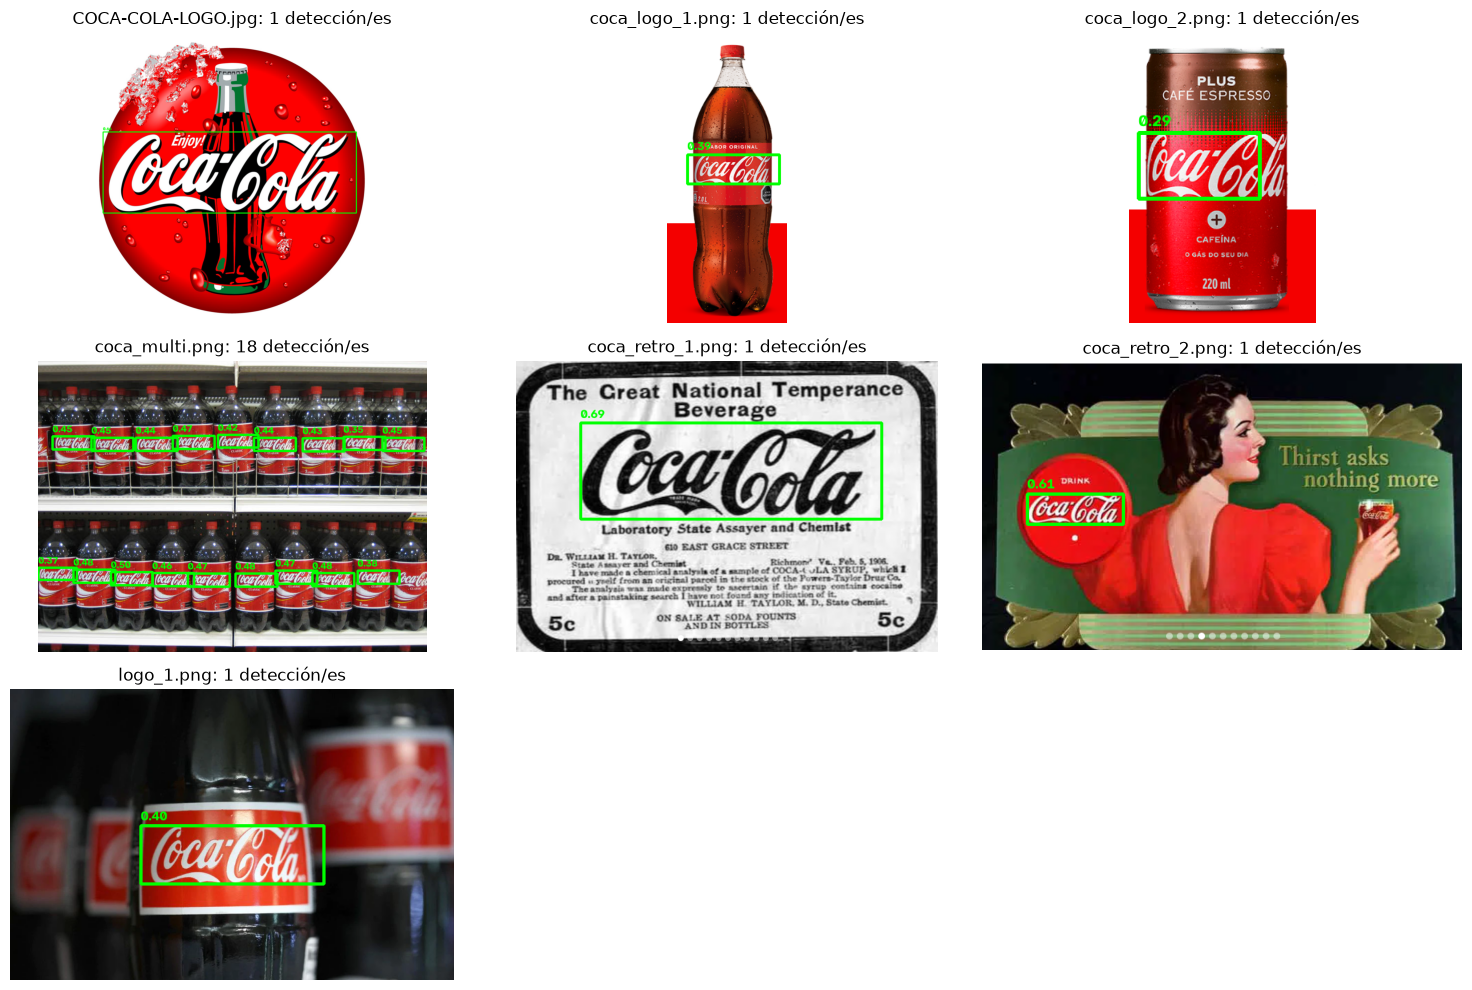

In [24]:
plt.figure(figsize=(15, 10))

for i, path in enumerate(image_paths):
    img_bgr = cv.imread(str(path))
    config = config_general[path.name]

    detecciones = detectar_logos(img_bgr, template_gray, **config)
    resultado = dibujar_detecciones(img_bgr, detecciones)

    plt.subplot(3, 3, i + 1)
    plt.imshow(cv.cvtColor(resultado, cv.COLOR_BGR2RGB))
    plt.title(f'{path.name}: {len(detecciones)} detección/es')
    plt.axis('off')

plt.tight_layout()
plt.show()